In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

/tmp/ipython-input-4053682251.py:577: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='score', data=model_score, ax=axes[0, 0], palette='viridis')


hallucination_type,Factual Error / Hallucination,Partial / Imprecise
model,,
Claude,6,4
GPT,4,4
Gemini,5,3



[난이도별 모델 성능 비교]


model,Claude,GPT,Gemini
difficulty,,,
easy,0.791667,0.875000,0.875000
hard,1.000000,0.500000,1.000000
medium,0.694444,0.805556,0.722222



[Skill Tag별 모델 성능 히트맵 데이터]


skill_tag,COMPARATIVE_REASONING,CONCEPT_DEFINITION,MISCONCEPTION_JUDGEMENT,NUMERIC_FACT,NUMERIC_REASONING_MULTI,RECENT_FACT,SIMPLE_FACT,image_reasoning
model,,,,,,,,
Claude,0.250,0.9,0.500,1.0,1.000000,1.0,0.75,0.625
GPT,0.625,0.9,0.625,1.0,0.500000,1.0,0.75,1.000
Gemini,0.500,0.8,0.750,1.0,0.833333,1.0,0.75,0.750


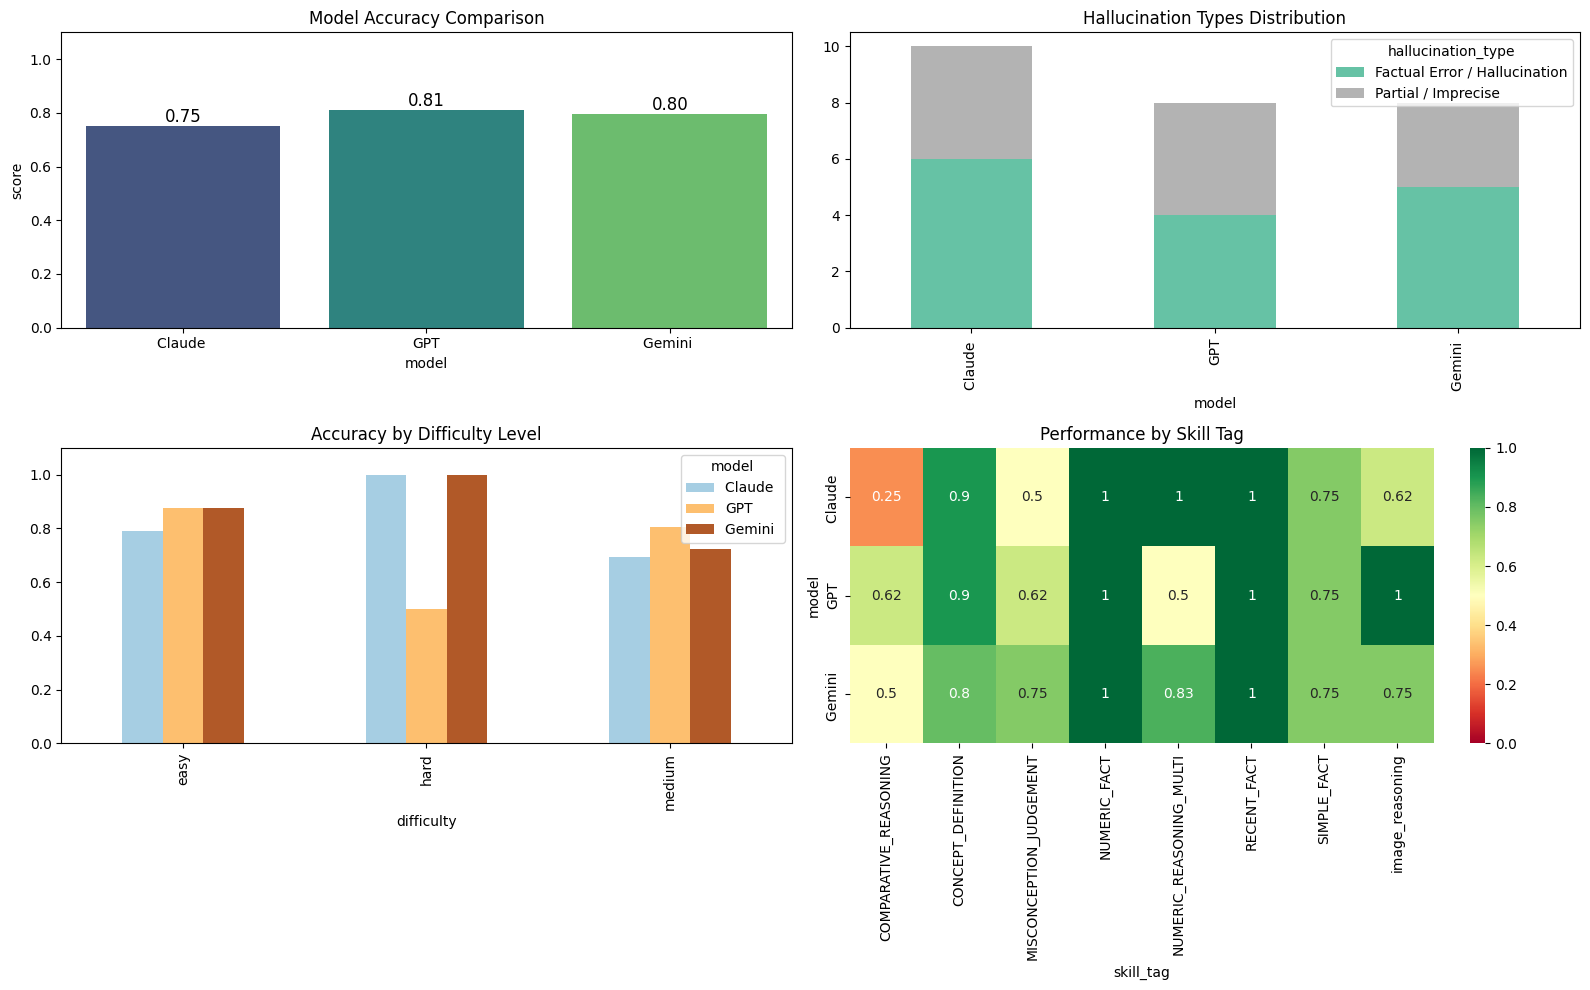


✅ 분석 완료! 결과가 'final_scored_results.csv'로 저장되었습니다.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import platform

# ==========================================
# 0. 한글 폰트 설정
# ==========================================
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':  # Mac
    plt.rc('font', family='AppleGothic')
else:  # Linux (Colab 등)
    # Colab에서 한글 폰트 설치 및 적용
    !sudo apt-get install -y fonts-nanum
    !sudo fc-cache -fv
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 병합 (사용자 코드 반영)
# ==========================================
# 파일 경로를 상황에 맞게 수정해주세요
try:
    responses_df = pd.read_csv('/content/drive/MyDrive/responses.csv')
    answers_df = pd.read_csv('/content/drive/MyDrive/answers.csv')

    # 컬럼명 공백 제거
    responses_df.columns = [c.strip() for c in responses_df.columns]
    answers_df.columns = [c.strip() for c in answers_df.columns]

    # 데이터 병합 (id 기준)
    merged_df = pd.merge(responses_df, answers_df, on='id', how='left')

    # [중요] 이후 로직에서 'q_id'를 사용하므로 컬럼명 통일 (id -> q_id)
    merged_df.rename(columns={'id': 'q_id'}, inplace=True)

    print("✅ 데이터 로드 및 병합 완료!")
    print(f"총 데이터 개수: {len(merged_df)}")

except FileNotFoundError:
    print("❌ 오류: 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    # 코드가 멈추지 않도록 빈 데이터프레임 생성 (실행 방지용)
    merged_df = pd.DataFrame()

# ==========================================
# 2. 정답 데이터베이스 (Ground Truth DB)
# ==========================================
ground_truth_db = {
    1: {
        "id": 1,
        "category": "fact",
        "question": "세계에서 가장 오래된 대학은 어디인가?",
        "correct": ["알카라윈", "kairaouine"],
        "partial": ["페스", "모로코", "mosque"],
    },
    2: {
        "id": 2,
        "category": "fact",
        "question": "인류가 처음 달에 착륙한 해는 언제인가?",
        "correct": ["1969"],
        "partial": [],
    },
    3: {
        "id": 3,
        "category": "fact",
        "question": "노벨상을 최초로 수상한 여성은 누구인가?",
        "correct": ["marie curie", "퀴리", "마리 퀴리"],
        "partial": ["마리", "노벨", "nobel", "여성"],
    },
    4: {
        "id": 4,
        "category": "fact",
        "question": "세계에서 가장 긴 강은 무엇인가?",
        "correct": ["nile", "나일", "amazon", "아마존"],
        "partial": ["강", "river"],
    },
    5: {
        "id": 5,
        "category": "numerical",
        "question": "대한민국의 2024년 출생아 수는 얼마인가?",
        "correct": ["238300", "238,300", "23만"],
        "partial": [],
    },
    6: {
        "id": 6,
        "category": "numerical",
        "question": "지구의 적도 둘레 길이는 약 몇 km인가?",
        "correct": ["40075", "40075.017", "40075.02", "40000", "40,000", "40,075", "4만"],
        "partial": [],
    },
    7: {
        "id": 7,
        "category": "numerical",
        "question": "2024년 대한민국 1인당 국민총소득(GNI)은 약 얼마인가?",
        "correct": ["5천만원", "36624달러"],
        "partial": [],
        "type": "range",
        "krw_range": (49000000, 50000000),
        "usd_range": (36000, 37000),
    },
    8: {
        "id": 8,
        "category": "numerical",
        "question": "대한민국의 2025년 최저임금은 시간당 얼마인가?",
        "correct": ["10030"],
        "partial": [],
        "type": "range",
        "range": (10000, 10100),
    },
    9: {
        "id": 9,
        "category": "definition",
        "question": "기계학습에서 '과적합(overfitting)'이란 무엇인가?",
        "correct_all": [
            ["과도", "excessive", "노이즈"],
            ["학습", "training"],
            ["성능", "performance"],
            ["떨어지", "저하", "감소", "decline", "decrease", "악화", "하락"]
        ],
        "partial": ["훈련", "데이터", "모델"],
        "type": "multi_group"
    },
    10: {
        "id": 10,
        "category": "definition",
        "question": "물리학에서 '엔트로피(entropy)'란 무엇인가?",
        "correct_all": [
            ["무질서", "disorder"],
        ],
        "partial": [],
        "type": "multi_group"
    },
    11: {
        "id": 11,
        "category": "definition",
        "question": "경제학의 '인플레이션(inflation)'을 정의하라.",
        "correct_all": [
            ["물가", "가격", "price"],
            ["상승", "증가", "increase", "rise"]
        ],
        "partial": [],
        "type": "multi_group"
    },
    12: {
        "id": 12,
        "category": "definition",
        "question": "인공지능에서 '강화학습(reinforcement learning)'이란 무엇인가?",
        "correct_all": [
            ["상호작용", "interaction"],
            ["보상", "reward"],
            ["최대화", "maximize"],
            ["학습", "learning"]
        ],
        "partial": [],
        "type": "multi_group_conditional",
        "scoring_rules": {
            "full_match": 1.0,
            "partial_match": 0.5,
            "insufficient": 0.0
        }
    },
    13: {
        "id": 13,
        "category": "recent",
        "question": "2024년 미국 대선에서 주요 후보는 누구였는가?",
        "correct": ["해리스", "harris", "트럼프", "trump"],
        "partial": [],
        "type": "simple"
    },
    14: {
        "id": 14,
        "category": "recent",
        "question": "2025년 노벨 물리학상 수상자는 누구였는가?",
        "correct": ["존 클라크", "john clarke", "미셸 드보레", "michel devoret", "존 마르티니스", "john martinis", "클라크", "드보레", "마르티니스"],
        "partial": [],
        "type": "simple"
    },
    15: {
        "id": 15,
        "category": "recent",
        "question": "2024 파리 올림픽 개막일은 언제였는가?",
        "correct": ["7월 26일", "july 26", "7월 26", "7/26", "26일"],
        "partial": [],
        "type": "simple"
    },
    16: {
        "id": 16,
        "category": "recent",
        "question": "2025년 공개된 영화 케이팝 데몬 헌터스의 감독은 누구인가?",
        "correct": [
            ["매기 강", "maggie kang", "매기"],
            ["크리스 아펠한스", "chris appelhans", "아펠한스"]
        ],
        "partial": [],
        "type": "multi_group",
        "scoring": {
            "both": 1.0,
            "one": 0.5
        }
    },
    17: {
        "id": 17,
        "category": "numerical",
        "question": "최저임금 월급 및 실수령액 계산",
        "correct": ["1203600", "1,203,600", "120만", "1163881", "1,163,881", "116만"],
        "partial": [],
        "type": "range",
        "monthly_salary_range": (1203600, 1203600),
        "net_salary_range": (1163000, 1164000),
        "both_required": True,
    },
    18: {
        "id": 18,
        "category": "calculation",
        "question": "A앱 vs B앱 택시비 비교",
        "correct": ["b앱", "B앱", "5000", "5,000"],
        "partial": ["a앱", "A앱", "5100", "5,100"],
        "type": "simple"
    },
    19: {
        "id": 19,
        "category": "calculation",
        "question": "카페 A vs B 혜택 비교",
        "correct": ["카페 b", "B카페", "b", "B"],
        "partial": ["카페 a", "A카페", "a", "A", "13잔", "13"],
        "type": "simple"
    },
    20: {
        "id": 20,
        "category": "numerical",
        "question": "영화 연간 시청 편수 및 편당 비용",
        "correct": ["60", "60편", "3400", "3,400", "3400원"],
        "partial": [],
        "type": "simple",
        "both_required": True
    },
    21: {
        "id": 21,
        "category": "comparison",
        "question": "MacBook vs Windows 노트북 비교",
        "correct_all": [
            ["성능", "performance"],
            ["호환성", "compatibility"],
            ["사용성", "usability"],
            ["MacBook", "M2", "갤럭시", "Galaxy", "windows", "macOS"]
        ],
        "partial": [],
        "type": "multi_group",
        "scoring": {
            "full_match": 1.0,
            "partial": 0.5
        }
    },
    22: {
        "id": 22,
        "category": "practical",
        "question": "대방역→한양대 이동 경로",
        "bus_required": ["641", "문래역", "2호선", "한양대역"],
        "subway_required": ["1호선", "대방역", "시청역", "2호선", "한양대역"],
        "partial": [],
        "type": "practical_route",
        "scoring": {
            "bus_complete": 0.5,
            "subway_complete": 0.5,
            "both": 1.0
        }
    },
    23: {
        "id": 23,
        "category": "comparison",
        "question": "풍력발전과 태양광발전 비교",
        "correct_all": [
            ["태양광", "solar"],
            ["풍력", "wind"],
            ["청정", "무제한", "유지보수", "수명"],
            ["일사량", "에너지밀도", "설치면적", "초기투자비"],
            ["연료비", "밤낮", "기술", "발전 가능"],
            ["변동성", "바람조건", "부지", "소음", "진동"]
        ],
        "partial": [],
        "type": "multi_group_strict",
        "scoring": {
            "full_match": 1.0,
            "partial_match": 0.5,
            "no_match": 0.0
        }
    },
    24: {
        "id": 24,
        "category": "definition",
        "question": "정규화와 표준화 차이",
        "normalization_required": ["정규화", "normalization", "데이터", "스케일링", "scale"],
        "standardization_required": ["표준화", "standardization", "평균", "mean", "표준편차", "standard deviation", "변환", "transform"],
        "partial": [],
        "type": "definition_compare",
        "scoring": {
            "both": 1.0,
            "one": 0.5,
            "none": 0.0
        }
    },
    25: {
        "id": 25,
        "category": "myth",
        "question": "인간이 뇌의 10%만 사용한다는 주장은 사실인가?",
        "correct_group1": ["과학적 근거", "근거 없다", "거짓", "신화"],
        "correct_group2": ["대부분", "뇌 영역", "사용한다"],
        "partial": [],
        "type": "myth_check",
        "scoring": {
            "group1": 1.0,
            "group2": 1.0,
            "none": 0.0
        }
    },
    26: {
        "id": 26,
        "category": "myth",
        "question": "소가 빨간색을 보면 흥분한다는 말은 사실인가?",
        "correct": ["아니다", "색을 구분", "구분하지 못", "움직임에 반응", "움직임"],
        "partial": [],
        "type": "simple"
    },
    27: {
        "id": 27,
        "category": "medical",
        "question": "비타민 C가 감기를 예방한다는 말",
        "correct": ["효과 없다", "없다", "예방", "감기 증상", "줄일 수"],
        "partial": [],
        "type": "simple"
    },
    28: {
        "id": 28,
        "category": "myth",
        "question": "설탕이 아이들을 과잉행동하게 만든다?",
        "correct": ["인과관계 없다", "없다", "사실 아니다", "근거 없다"],
        "partial": [],
        "type": "simple"
    },
    29: {
        "id": 29,
        "category": "calculation",
        "question": "문구점별 공책 수 계산",
        "correct": ["53", "53권"],
        "partial": ["30", "30권", "23", "23권"],
        "type": "simple"
    },
    30: {
        "id": 30,
        "category": "graph",
        "question": "가장 좋아하는 과일 통계",
        "correct": ["귤", "14"],
        "partial": [],
        "type": "simple"
    },
    31: {
        "id": 31,
        "category": "matching",
        "question": "혁주, 은영, 준수의 운동 매칭",
        "correct_all": [
            ["혁주", "농구"],
            ["은영", "테니스"],
            ["준수", "축구"]
        ],
        "partial": [],
        "type": "matching_pair",
        "scoring": {
            "full_match": 1.0,
            "partial": 0.5,
            "none": 0.0
        }
    },
    32: {
        "id": 32,
        "category": "calculation",
        "question": "곡물 소비량 계산",
        "correct_all": [
            ["쌀", "280"],
            ["보리", "224"],
            ["콩", "176"],
            ["기타", "120"]
        ],
        "partial": [],
        "type": "matching_pair",
        "scoring": {
            "full_match": 1.0,
            "partial": 0.5,
            "none": 0.0
        }
    }
}

# ==========================================
# 3. 채점 로직 함수 (calculate_score)
# ==========================================
def calculate_score(q_id, response, ground_truth_db):
    if q_id not in ground_truth_db:
        return 0.0

    q_data = ground_truth_db[q_id]
    q_type = q_data.get("type", "simple")

    # 텍스트 정규화
    response_lower = str(response).strip().lower()

    # 리스트 로드
    correct_list = q_data.get("correct", [])
    partial_list = q_data.get("partial", [])
    group_list = q_data.get("correct_all", q_data.get("correct", []))

    score = 0.0

    # ---------------------------------------------------------
    # [Section 1] ID별 특수 로직
    # ---------------------------------------------------------
    if q_id == 7 and q_type == "range":
        response_normalized = str(response).replace("만", "0000").replace("천", "000")
        response_numbers = re.findall(r'\d+', response_normalized.replace(",", ""))
        response_ints = [int(num) for num in response_numbers]
        krw_min, krw_max = q_data["krw_range"]
        usd_min, usd_max = q_data["usd_range"]
        if any(krw_min <= num <= krw_max for num in response_ints): score = 1.0
        elif any(usd_min <= num <= usd_max for num in response_ints): score = 1.0

    elif q_id == 8 and q_type == "range":
        response_normalized = str(response).replace("만", "0000").replace("천", "000")
        response_numbers = re.findall(r'\d+', response_normalized.replace(",", ""))
        response_ints = [int(num) for num in response_numbers]
        min_val, max_val = q_data["range"]
        if any(min_val <= num <= max_val for num in response_ints): score = 1.0

    elif q_id == 17:
        response_normalized = str(response).replace("만", "0000").replace("천", "000")
        response_numbers = re.findall(r'\d+', response_normalized.replace(",", ""))
        response_ints = [int(num) for num in response_numbers]
        m_min, m_max = q_data["monthly_salary_range"]
        n_min, n_max = q_data["net_salary_range"]
        monthly_ok = any(m_min <= num <= m_max or (num < 10000 and m_min <= num * 10000 <= m_max) for num in response_ints)
        net_ok = any(n_min - 100 <= num <= n_max + 100 for num in response_ints)
        if monthly_ok and net_ok: score = 1.0
        elif monthly_ok or net_ok: score = 0.5

    elif q_id == 20:
        annual_correct = any(k in response_lower for k in ["60", "60편"])
        cost_correct = any(k in response_lower for k in ["3400", "3,400", "3400원"])
        if annual_correct and cost_correct: score = 1.0
        elif annual_correct or cost_correct: score = 0.5

    elif q_id == 22:
        bus_keywords = q_data["bus_required"]
        subway_keywords = q_data["subway_required"]
        bus_score = 0.5 if all(k.lower() in response_lower for k in bus_keywords) else 0.0
        subway_score = 0.5 if all(k.lower() in response_lower for k in subway_keywords) else 0.0
        score = bus_score + subway_score

    elif q_id == 23:
        groups = group_list
        present_indices = [i for i, group in enumerate(groups) if any(k.lower() in response_lower for k in group)]
        if len(present_indices) == 6: score = 1.0
        elif {0, 2, 3}.issubset(set(present_indices)) or {1, 4, 5}.issubset(set(present_indices)): score = 0.5
        elif {2, 4}.issubset(set(present_indices)) or {3, 5}.issubset(set(present_indices)): score = 0.5

    elif q_id == 24:
        norm_keywords = q_data["normalization_required"]
        std_keywords = q_data["standardization_required"]
        norm_cnt = sum(1 for k in norm_keywords if k.lower() in response_lower)
        std_cnt = sum(1 for k in std_keywords if k.lower() in response_lower)
        norm_ok = norm_cnt >= 2
        std_ok = std_cnt >= 2
        if norm_ok and std_ok: score = 1.0
        elif norm_ok or std_ok: score = 0.5

    elif q_id == 25:
        group1_present = any(k.lower() in response_lower for k in q_data["correct_group1"])
        group2_present = any(k.lower() in response_lower for k in q_data["correct_group2"])
        if group1_present: score = 1.0
        elif group2_present: score = 0.5

    # ---------------------------------------------------------
    # [Section 2] 범용 Type별 로직
    # ---------------------------------------------------------
    elif q_type == "multi_group_conditional":
        present_groups = [i for i, group in enumerate(group_list) if any(k.lower() in response_lower for k in group)]
        if len(present_groups) == 4: score = 1.0
        elif 0 in present_groups and 2 in present_groups: score = 1.0
        elif len(present_groups) >= 2: score = 0.5

    elif q_type == "multi_group":
        matched_count = 0
        for group in group_list:
            if isinstance(group, list):
                if any(k.lower() in response_lower for k in group): matched_count += 1
            else:
                if group.lower() in response_lower: matched_count += 1
        total_groups = len(group_list)
        scoring_rules = q_data.get("scoring", {})
        if q_id == 16:
            if matched_count == 2: score = 1.0
            elif matched_count == 1: score = 0.5
        elif scoring_rules:
            if matched_count == total_groups: score = scoring_rules.get("full_match", 1.0)
            elif matched_count >= total_groups / 2: score = scoring_rules.get("partial", 0.5)
            elif matched_count >= 1 and "one" in scoring_rules: score = scoring_rules.get("one", 0.5)
        else:
            if matched_count == total_groups: score = 1.0
            elif matched_count >= 1: score = 0.5
            elif any(k in response_lower for k in partial_list): score = 0.5

    elif q_type == "matching_pair":
        matched_groups = sum(1 for group in group_list if all(k.lower() in response_lower for k in group))
        total_pairs = len(group_list)
        if matched_groups == total_pairs: score = 1.0
        elif matched_groups >= 1: score = 0.5

    # ---------------------------------------------------------
    # [Section 3] 기본형 (Fact, Simple, Recent 등)
    # ---------------------------------------------------------
    else:
        is_correct = any(str(k).lower() in response_lower for k in correct_list)
        is_partial = any(str(k).lower() in response_lower for k in partial_list)
        if is_correct: score = 1.0
        elif is_partial: score = 0.5

    return score

# ==========================================
# 4. 채점 및 결과 분석 함수 (Wrapper)
# ==========================================
def evaluate_answer(row):
    # 컬럼명이 'id'인지 'q_id'인지 확인하여 사용
    q_id = row.get('q_id', row.get('id'))
    response = row['responses'] # Changed 'response' to 'responses'

    if pd.isna(q_id):
        return pd.Series([0.0, "Error"])

    # 점수 계산
    score = calculate_score(int(q_id), response, ground_truth_db)

    # Hallucination Type 판별
    if score == 1.0:
        h_type = "None"
    elif score == 0.5:
        h_type = "Partial / Imprecise"
    else:
        h_type = "Factual Error / Hallucination"

    return pd.Series([score, h_type])

# ================================================================================
# 5. 실행 및 결과 집계
# ================================================================================

if not merged_df.empty:
    print("\n🚀 채점을 시작합니다...")

    # 1) 채점 실행
    merged_df[['score', 'hallucination_type']] = merged_df.apply(evaluate_answer, axis=1)

    # 2) 모델별 평균 점수 확인
    if 'model' in merged_df.columns:
        model_score = merged_df.groupby('model')['score'].mean().reset_index()
        print("\n[모델별 평균 점수]")
        print(model_score)
    else:
        print("⚠ 'model' 컬럼이 없어 모델별 비교를 건너뜁니다.")

    # ----------------- 시각화 -----------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # [1] 모델별 정확도
    if 'model' in merged_df.columns:
        sns.barplot(x='model', y='score', data=model_score, ax=axes[0, 0], palette='viridis')
        axes[0, 0].set_title('Model Accuracy Comparison')
        axes[0, 0].set_ylim(0, 1.1)
        for p in axes[0, 0].patches:
            axes[0, 0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='bottom', fontsize=12)
    else:
        axes[0, 0].text(0.5, 0.5, 'Model column missing', ha='center')

    # [2] Hallucination 유형 분포
    if 'model' in merged_df.columns:
        hallu_counts = merged_df[merged_df['score'] < 1.0].groupby(['model', 'hallucination_type']).size().unstack(fill_value=0)
        print("\n[모델별 Hallucination 유형 분포]")
        display(hallu_counts)
        if not hallu_counts.empty:
            hallu_counts.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Set2')
            axes[0, 1].set_title('Hallucination Types Distribution')
        else:
            axes[0, 1].text(0.5, 0.5, 'No Errors Detected', ha='center')
    else:
         axes[0, 1].text(0.5, 0.5, 'Model column missing', ha='center')

    # [3] 난이도별 성능 비교
    if 'difficulty' in merged_df.columns and 'model' in merged_df.columns:
        difficulty_score = merged_df.groupby(['difficulty', 'model'])['score'].mean().unstack()
        print("\n[난이도별 모델 성능 비교]")
        display(difficulty_score)
        difficulty_score.plot(kind='bar', ax=axes[1, 0], colormap='Paired')
        axes[1, 0].set_title('Accuracy by Difficulty Level')
        axes[1, 0].set_ylim(0, 1.1)
    else:
        axes[1, 0].text(0.5, 0.5, 'Difficulty or Model column missing', ha='center')

    # [4] Skill Tag별 성능 Heatmap
    if 'skill_tag' in merged_df.columns and 'model' in merged_df.columns:
        skill_pivot = merged_df.pivot_table(index='model', columns='skill_tag', values='score', aggfunc='mean')
        print("\n[Skill Tag별 모델 성능 히트맵 데이터]")
        display(skill_pivot)
        sns.heatmap(skill_pivot, annot=True, cmap='RdYlGn', vmin=0, vmax=1, ax=axes[1, 1])
        axes[1, 1].set_title('Performance by Skill Tag')
    else:
        axes[1, 1].text(0.5, 0.5, 'Skill_tag or Model column missing', ha='center')

    # 모든 서브플롯의 격자 제거
    for ax_row in axes:
        for ax in ax_row:
            ax.grid(False)

    plt.tight_layout()
    plt.show()

    # 최종 결과 저장
    merged_df.to_csv('final_scored_results.csv', index=False)
    print("\n✅ 분석 완료! 결과가 'final_scored_results.csv'로 저장되었습니다.")

else:
    print("❌ 데이터가 없어 채점을 진행할 수 없습니다.")

/tmp/ipython-input-646623588.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='variance', data=model_variance, palette='coolwarm')



📌 모델별 분산(Variance) 계산
     model  variance
0  Claude   0.161290
1      GPT  0.125000
2  Gemini   0.142893


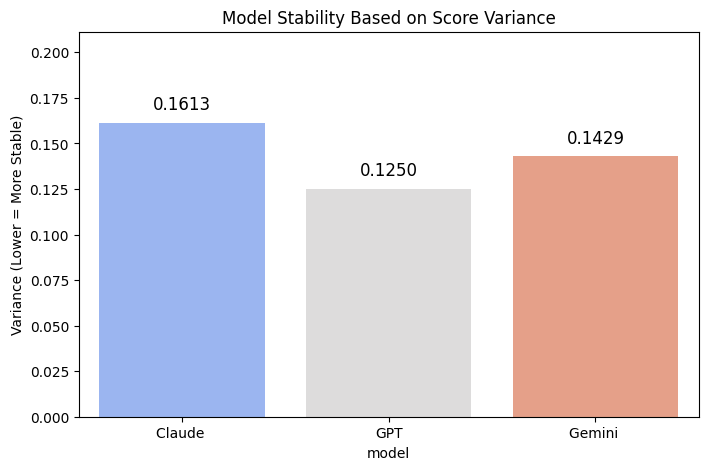

In [ ]:
# ==========================================
# 모델별 분산(안정성) 계산
# ==========================================

if 'model' in merged_df.columns and 'score' in merged_df.columns:
    print("\n📌 모델별 분산(Variance) 계산")

    # 모델별 점수 분산
    model_variance = merged_df.groupby('model')['score'].var().reset_index()
    model_variance.columns = ['model', 'variance']

    print(model_variance)

    # 시각화
    plt.figure(figsize=(8, 5))
    sns.barplot(x='model', y='variance', data=model_variance, palette='coolwarm')

    plt.title('Model Stability Based on Score Variance')
    plt.ylabel('Variance (Lower = More Stable)')
    plt.ylim(0, model_variance['variance'].max() + 0.05)

    # 각 바 위에 값 표시
    for i, row in model_variance.iterrows():
        plt.text(i, row['variance'] + 0.005, f"{row['variance']:.4f}",
                 ha='center', va='bottom', fontsize=12)

    plt.show()

else:
    print("❌ 'model' 또는 'score' 컬럼이 없어 분산 계산 불가.")


📌 난이도별 분산 계산 시작

📊 [난이도별 분산표]
model        Claude        GPT   Gemini 
difficulty                              
easy        0.111742  0.096591  0.096591
hard        0.000000  0.500000  0.000000
medium      0.209967  0.121732  0.183007


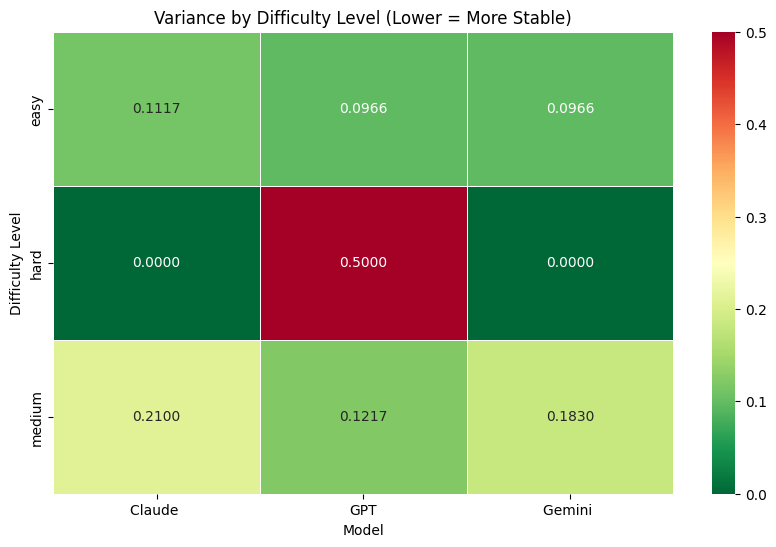

In [ ]:
# ==========================================
# 난이도별 분산 계산 (Variance by Difficulty)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sanity check
required_cols = ['difficulty', 'model', 'score']
if not all(col in merged_df.columns for col in required_cols):
    print("❌ 필요한 컬럼이 없습니다. ('difficulty', 'model', 'score')")
else:
    print("📌 난이도별 분산 계산 시작")

    # 1) 난이도별 모델 점수 분산 계산
    difficulty_variance = merged_df.groupby(['difficulty', 'model'])['score'].var().unstack()

    print("\n📊 [난이도별 분산표]")
    print(difficulty_variance)

    # 2) 시각화
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        difficulty_variance,
        annot=True, fmt=".4f",
        cmap='RdYlGn_r',
        linewidths=.5
    )

    plt.title("Variance by Difficulty Level (Lower = More Stable)")
    plt.ylabel("Difficulty Level")
    plt.xlabel("Model")
    plt.show()


In [ ]:
difficulty_variance = merged_df.groupby(['difficulty', 'model'])['score'].var().unstack()
